In [1]:
from dateutil.parser import parse 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
plt.rcParams.update({'figure.figsize': (10, 7), 'figure.dpi': 120})

from statsmodels.tsa.seasonal import seasonal_decompose
from dateutil.parser import parse

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from matplotlib import pyplot

from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split


from math import sqrt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def mean_absolute_percentage_error(y_true, y_pred): 
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) 

In [2]:
############################################
## Dados diarios sobre mortalidade cardiovascular ##
############################################
df = pd.read_csv('C:/Users/crisr/Documents/ASN_Rocks/Series_Temporais/2. Curso_Completo/Dados/globtemp2_1.txt')
df.head()

,value
0,-0.02
1,0.12
2,-0.03
3,-0.38
4,0.19


In [ ]:
################################
################################
#1. Visualizando a série temporal

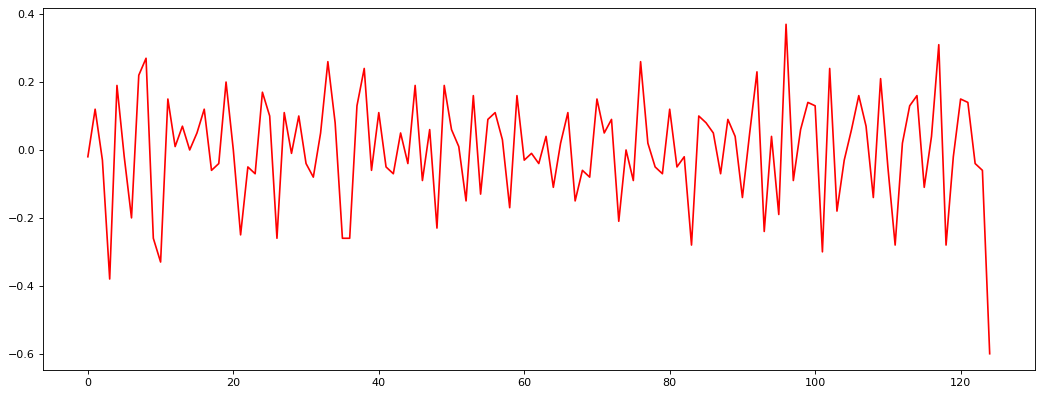

In [17]:
fig  = plt.subplots(1, figsize=(16,6), dpi= 80)
plt.plot(df, color='red')

In [ ]:
################################
################################
#2. Verificando se a série é um Ruído Branco
#Usando Teste Ljung-Box

In [3]:
sm.stats.acorr_ljungbox(df, lags=[5], return_df=True)

,lb_stat,lb_pvalue
5,18.725174,0.002162


p_valor < nível_significancia  => rejeitar a hipotese nula => série não é ruído branco

In [4]:
################################
################################
#3. Verificando se a série é Estacionária
# ADF test 
#ADF test, where the null hypothesis is the time series possesses a unit root and is non-stationary. 
#So, id the P-Value in ADH test is less than the significance level (0.05), you reject the null hypothesis.
result = adfuller(df.values, autolag='AIC')
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')
#for key, value in result[4].items():
#    print('Critial Values:')
#    print(f'   {key}, {value}')

ADF Statistic: -7.992294666130935
p-value: 2.4560284050276957e-12


p_valor < nível_significancia  => rejeita a hipotese nula => série é estacionaria

In [ ]:
################################
################################
#4. IDENTIFICAÇÃO
# Verificando autocorrelação e autocorrelação parcial

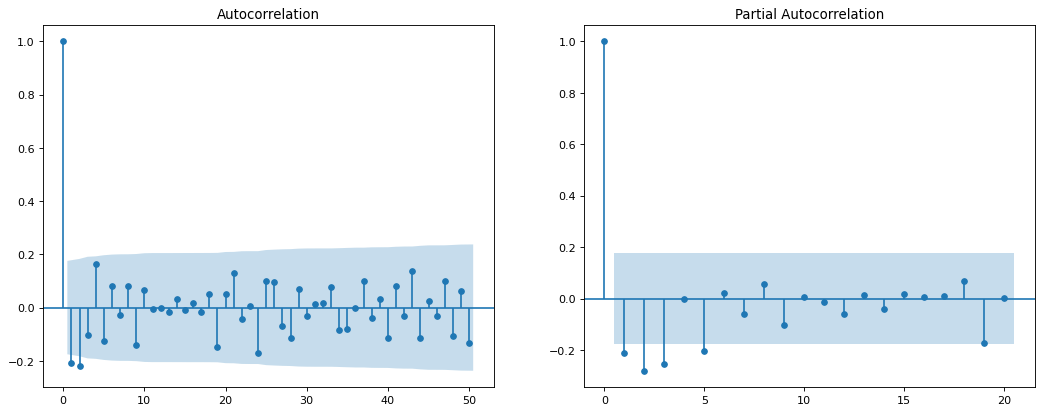

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(16,6), dpi= 80)
fig=plot_acf(df, ax=ax1, lags=50)
fig=plot_pacf(df, ax=ax2, lags=20)

In [ ]:
################################
################################
# 5. ESTIMAÇÃO
# Ajusta o modelo

In [6]:
model = ARIMA(df, order=(5, 0, 2))  
results_ARMA = model.fit()  
# summary of fit model
print(results_ARMA.summary())

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  125
Model:                 ARIMA(5, 0, 2)   Log Likelihood                  73.983
Date:                Mon, 06 Nov 2023   AIC                           -129.965
Time:                        20:20:56   BIC                           -104.510
Sample:                             0   HQIC                          -119.624
                                - 125                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0050      0.003      1.513      0.130      -0.001       0.012
ar.L1         -0.3746      0.375     -0.998      0.318      -1.111       0.361
ar.L2         -0.0600      0.286     -0.210      0.8

C:\Users\crisr\AppData\Roaming\Python\Python38\site-packages\statsmodels\base\model.py:566: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [22]:
y_true = df.values
y_pred = results_ARMA.fittedvalues
r2   = r2_score(y_true, y_pred)
mse  = mean_squared_error(y_true, y_pred)
rmse = sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred)

print('R2:   %.3f' % r2)
print('MSE:  %.3f' % mse)
print('RMSE: %.3f' % rmse)
print('MAE:  %.3f' % mae)
print('MAPE: %.3f' % mape)

R2:   0.285
MSE:  0.018
RMSE: 0.134
MAE:  0.100
MAPE: inf


C:\Users\crisr\AppData\Local\Temp/ipykernel_620/759244740.py:29: RuntimeWarning: divide by zero encountered in true_divide
  return np.mean(np.abs((y_true - y_pred) / y_true))


In [23]:
# a variável MA1 foi a menos significante
# então vamos removê-la do modelo
# basta usar a syntax abaixo para fazer isso
model = ARIMA(df, order=([5], 0, [2]))  
results_ARMA = model.fit()  
# summary of fit model
print(results_ARMA.summary())

#model = ARIMA(df, order=([1,2,3,5], 0, [2]))  

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  125
Model:               ARIMA(5, 0, [2])   Log Likelihood                  74.130
Date:                Tue, 21 Jun 2022   AIC                           -132.260
Time:                        20:33:08   BIC                           -109.633
Sample:                             0   HQIC                          -123.068
                                - 125                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0049      0.003      1.396      0.163      -0.002       0.012
ar.L1         -0.4768      0.121     -3.955      0.000      -0.713      -0.241
ar.L2         -0.1312      0.298     -0.441      0.6

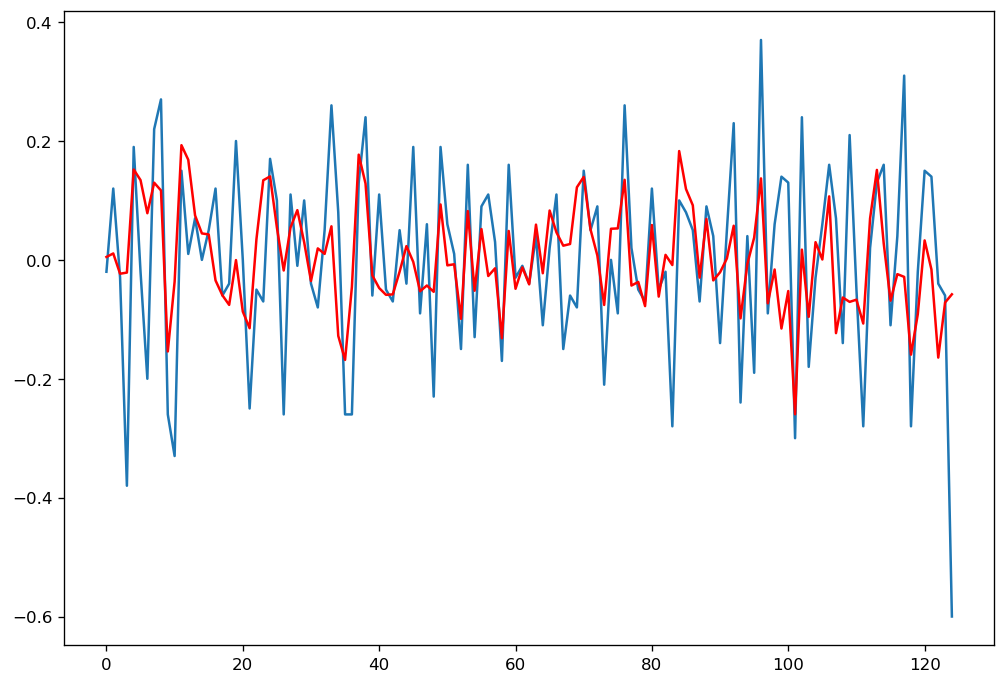

In [24]:
plt.plot(df)
plt.plot(results_ARMA.fittedvalues, color='red')

In [ ]:
################################
################################
# 6. VERIFICAÇÃO
# Avalia a qualidade do ajuste 

In [25]:
# Aplicando teste do ruido branco do resíduo
sm.stats.acorr_ljungbox(results_ARMA.resid, lags=[10], return_df=True)

,lb_stat,lb_pvalue
10,0.67752,0.999972


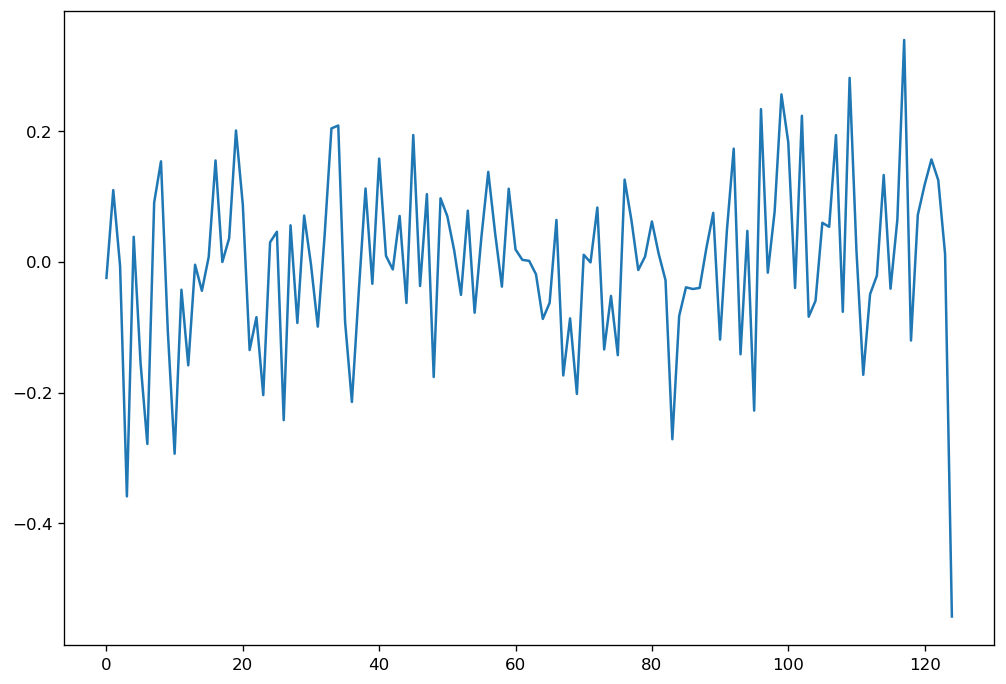

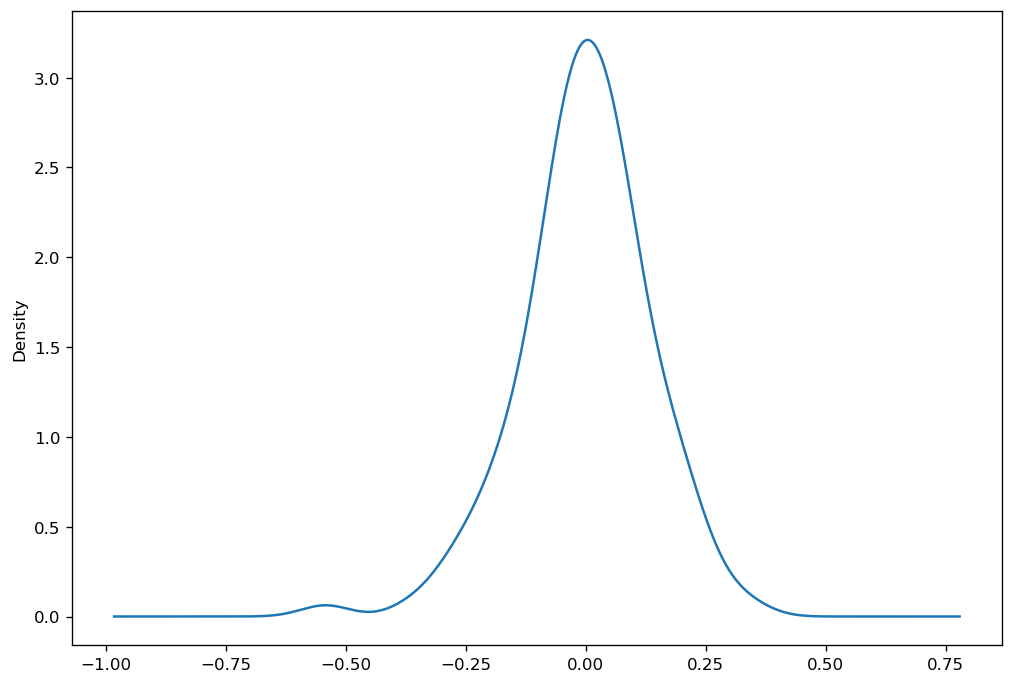

count    125.000000
mean      -0.001678
std        0.134183
min       -0.542093
25%       -0.076669
50%        0.002694
75%        0.074525
max        0.338600
dtype: float64


In [28]:
# Analisa também o residuo para verificar se satisfaz as condições de ruido branco
# line plot of residuals
residuals = results_ARMA.resid
residuals.plot()
pyplot.show()
# density plot of residuals
residuals.plot(kind='kde')
pyplot.show()
# summary stats of residuals
print(residuals.describe())

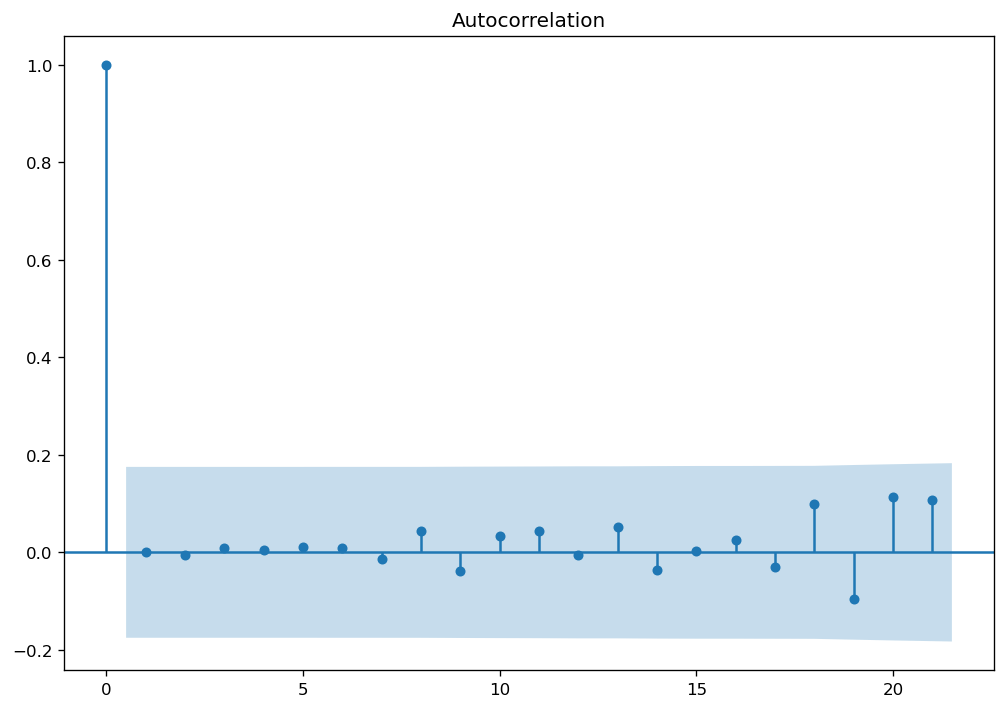

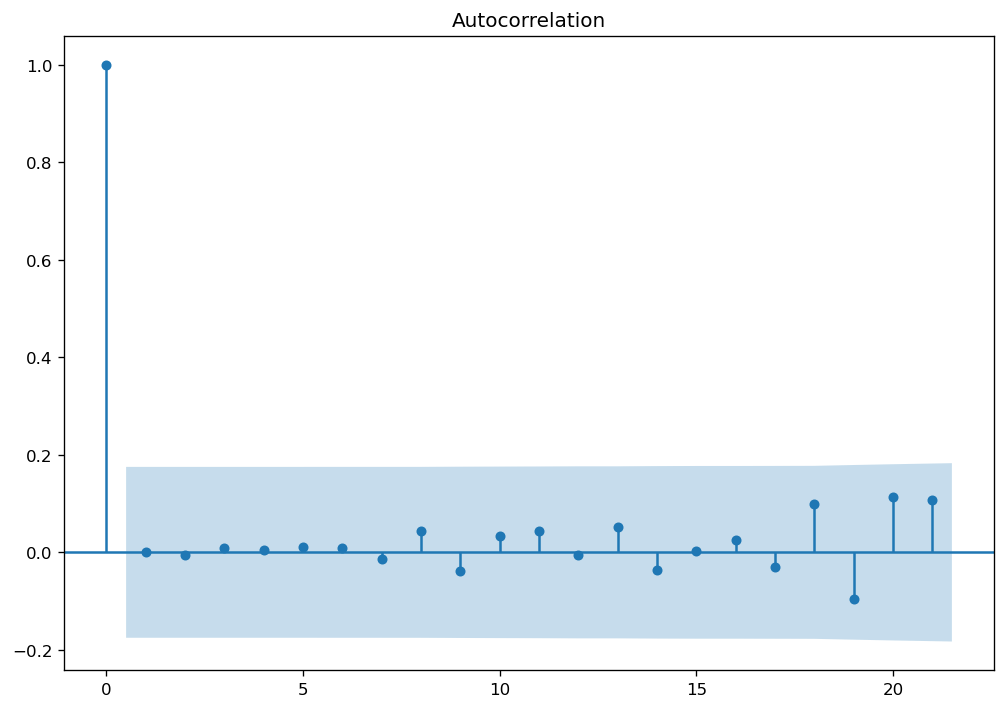

In [29]:
plot_acf(results_ARMA.resid)

In [26]:
################################
################################
# 6. PREVISÃO
predictions = results_ARMA.forecast(30)

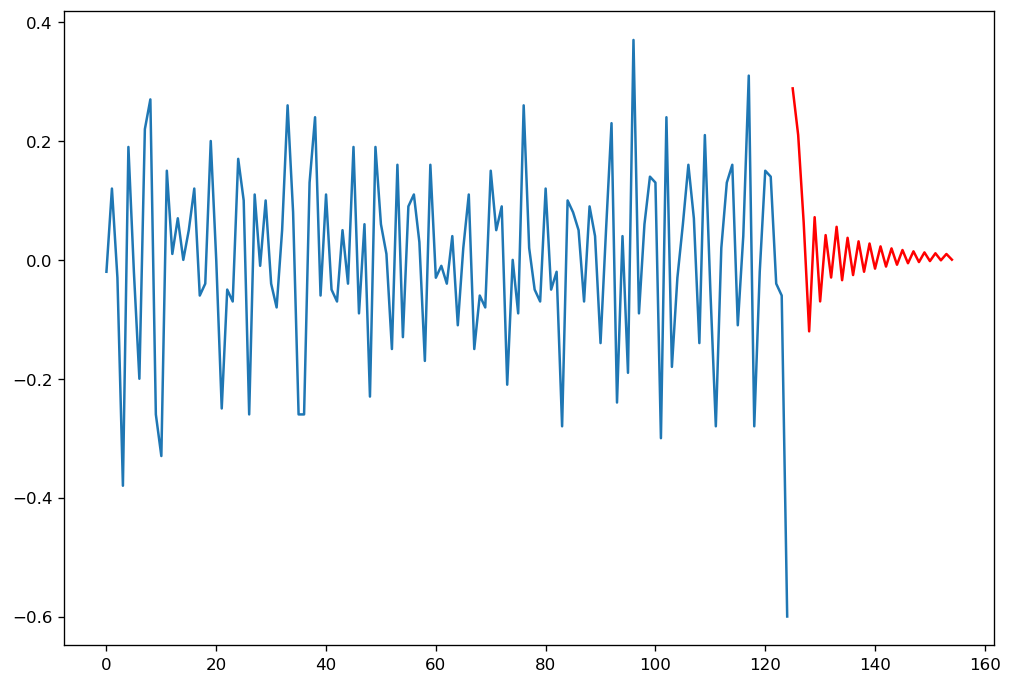

In [27]:
# plot forecasts against actual outcomes
pyplot.plot(df)
pyplot.plot(predictions, color='red')
pyplot.show()